In [114]:
# Load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("../data/train.csv")


/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_82574/4040572339.py:6: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/train.csv")


In [115]:
# Check the dataset
print(df.info())
print(df.describe())
# Check the data of each column
print("\nData sample:\n", df.head())
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

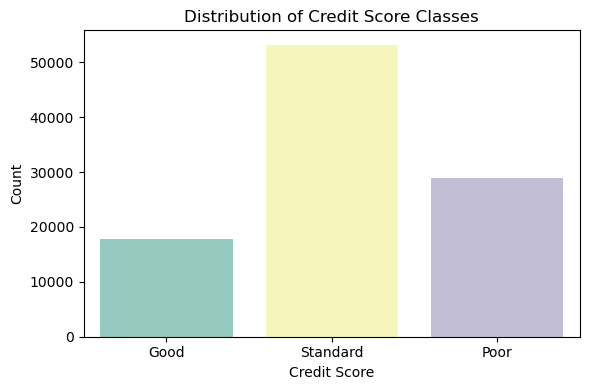

In [116]:
# EDA Visualize distributions of key features

# Distribution of target variable
#1 Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Credit_Score",hue="Credit_Score", palette="Set3")
plt.title("Distribution of Credit Score Classes")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()# Explore feature distributions by Credit Score

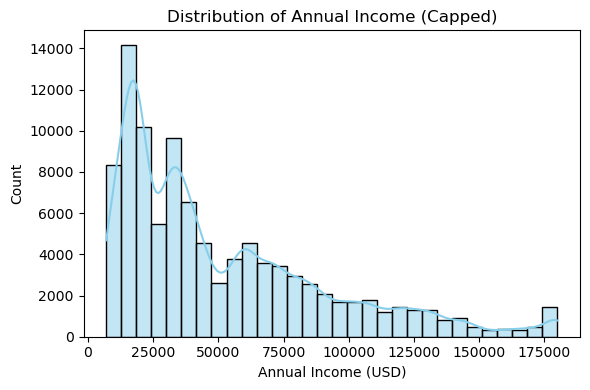

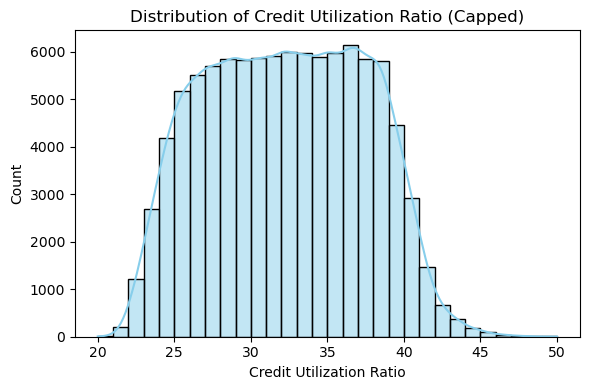

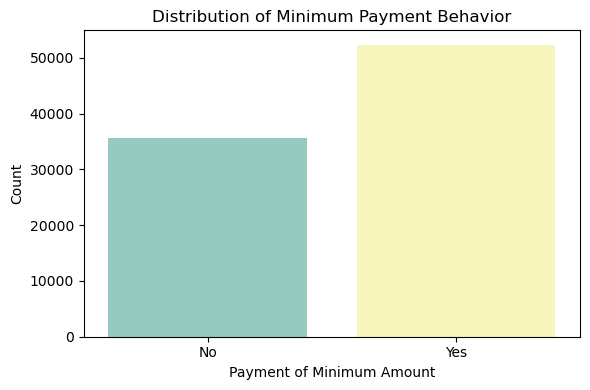

In [117]:
#Distributions of key features
# 1 Annual Income distribution
df_plot = df.copy()

df_plot["Annual_Income"] = (
    df_plot["Annual_Income"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("_", "", regex=False)
)

df_plot["Annual_Income"] = pd.to_numeric(df_plot["Annual_Income"], errors="coerce")

cap_value = df_plot["Annual_Income"].quantile(0.99)
df_plot["Annual_Income"] = np.minimum(df_plot["Annual_Income"], cap_value)

plt.figure(figsize=(6,4))
sns.histplot(
    data=df_plot,
    x="Annual_Income",
    kde=True,
    bins=30,
    color="skyblue"
)
plt.title("Distribution of Annual Income (Capped)")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2 Credit Utilization Ratio distribution
df_plot = df.copy()
df_plot["Credit_Utilization_Ratio"] = pd.to_numeric(df_plot["Credit_Utilization_Ratio"], errors="coerce")

cap = df_plot["Credit_Utilization_Ratio"]
df_plot["Credit_Utilization_Ratio"] = np.minimum(df_plot["Credit_Utilization_Ratio"], cap)

plt.figure(figsize=(6,4))
sns.histplot(
    data=df_plot,
    x="Credit_Utilization_Ratio",
    kde=True,
    bins=30,
    color="skyblue"
)
plt.title("Distribution of Credit Utilization Ratio (Capped)")
plt.xlabel("Credit Utilization Ratio")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3 Payment of Minimum Amount distribution
df_eda = df[df["Payment_of_Min_Amount"].isin(["Yes", "No"])]

plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x="Payment_of_Min_Amount", hue="Payment_of_Min_Amount", palette="Set3")
plt.title("Distribution of Minimum Payment Behavior")
plt.xlabel("Payment of Minimum Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

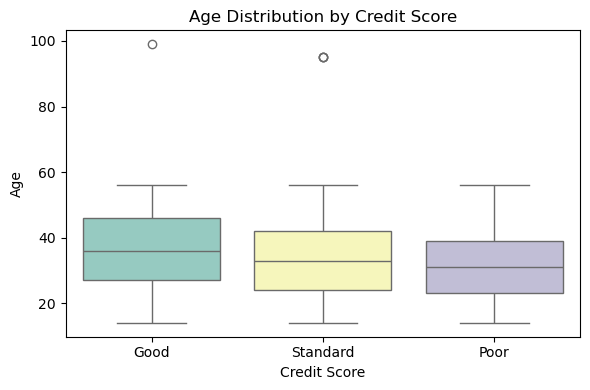

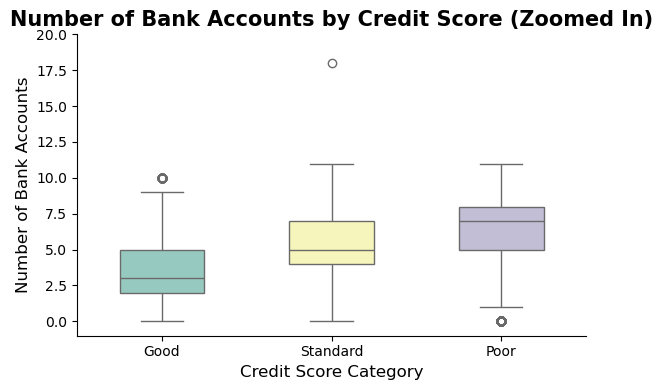

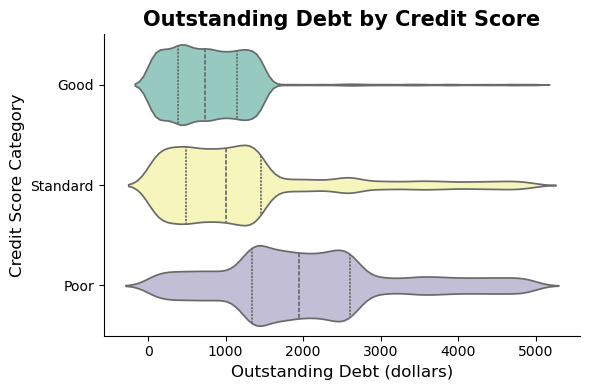

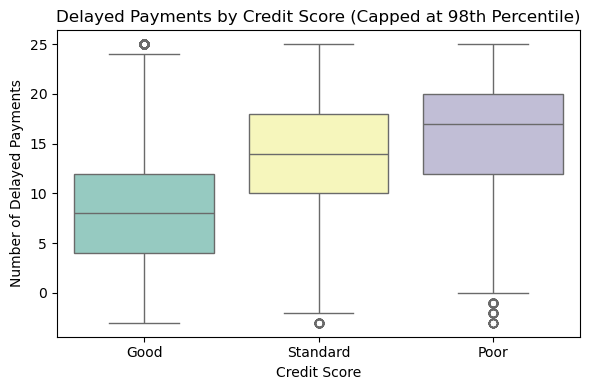

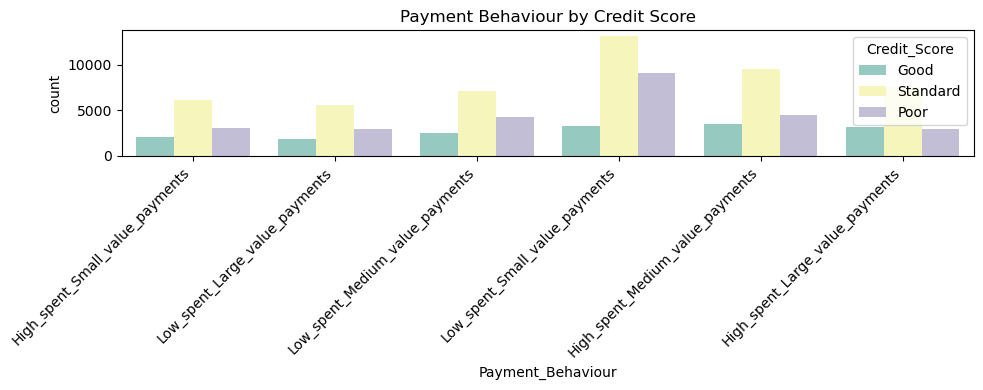

In [118]:
# Feature distributions by Credit Score
# 1 Age distribution by Credit Score
df_plot = df.copy()

df_plot["Age"] = pd.to_numeric(df_plot["Age"], errors="coerce")

df_plot = df_plot[(df_plot["Age"] > 0) & (df_plot["Age"] < 100)]

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Age",
    palette="Set3",
    order=["Good","Standard","Poor"]
)
plt.title("Age Distribution by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


# 2 Number of Bank Accounts distribution by Credit Score
df_plot = df.copy()
df_plot["Num_Bank_Accounts"] = pd.to_numeric(df_plot["Num_Bank_Accounts"], errors="coerce")
df_plot = df_plot[df_plot["Num_Bank_Accounts"] >= 0]

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Num_Bank_Accounts",
    order=["Good","Standard","Poor"],
    palette="Set3",
    width=0.5
)

plt.title("Number of Bank Accounts by Credit Score (Zoomed In)", fontsize=15, weight='bold')
plt.xlabel("Credit Score Category", fontsize=12)
plt.ylabel("Number of Bank Accounts", fontsize=12)

plt.ylim(-1, 20)

sns.despine()
plt.tight_layout()
plt.show()


# 3 Outstanding Debt distribution by Credit Score
df_plot = df.copy()

df_plot["Outstanding_Debt"] = (
    df_plot["Outstanding_Debt"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .replace("NA", np.nan)
)

df_plot["Outstanding_Debt"] = pd.to_numeric(df_plot["Outstanding_Debt"], errors="coerce")

plt.figure(figsize=(6,4))
sns.violinplot(
    data=df_plot,
    y="Credit_Score",
    x="Outstanding_Debt",
    hue="Credit_Score",
    order=["Good","Standard","Poor"],
    palette="Set3",
    inner="quartile"
)

plt.title("Outstanding Debt by Credit Score", fontsize=15, weight='bold')
plt.xlabel("Outstanding Debt (dollars)", fontsize=12)
plt.ylabel("Credit Score Category", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

# 4 Number of Delayed Payment distribution by Credit Score
df_plot = df.copy()
df_plot["Num_of_Delayed_Payment"] = pd.to_numeric(df_plot["Num_of_Delayed_Payment"], errors="coerce")

cap = df_plot["Num_of_Delayed_Payment"].quantile(0.98)
df_plot["Num_of_Delayed_Payment"] = np.minimum(df_plot["Num_of_Delayed_Payment"], cap)

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Num_of_Delayed_Payment",
    palette="Set3",
    order=["Good","Standard","Poor"]
)
plt.title("Delayed Payments by Credit Score (Capped at 98th Percentile)")
plt.xlabel("Credit Score")
plt.ylabel("Number of Delayed Payments")
plt.tight_layout()
plt.show()

# 5 Payment Behaviour distribution by Credit Score
df_plot = df[df["Payment_Behaviour"] != "!@9#%8"].copy()

plt.figure(figsize=(10,4))
sns.countplot(
    data=df_plot,
    x="Payment_Behaviour",
    hue="Credit_Score",
    palette="Set3"
)
plt.xticks(rotation=45, ha="right")
plt.title("Payment Behaviour by Credit Score")
plt.tight_layout()
plt.show()

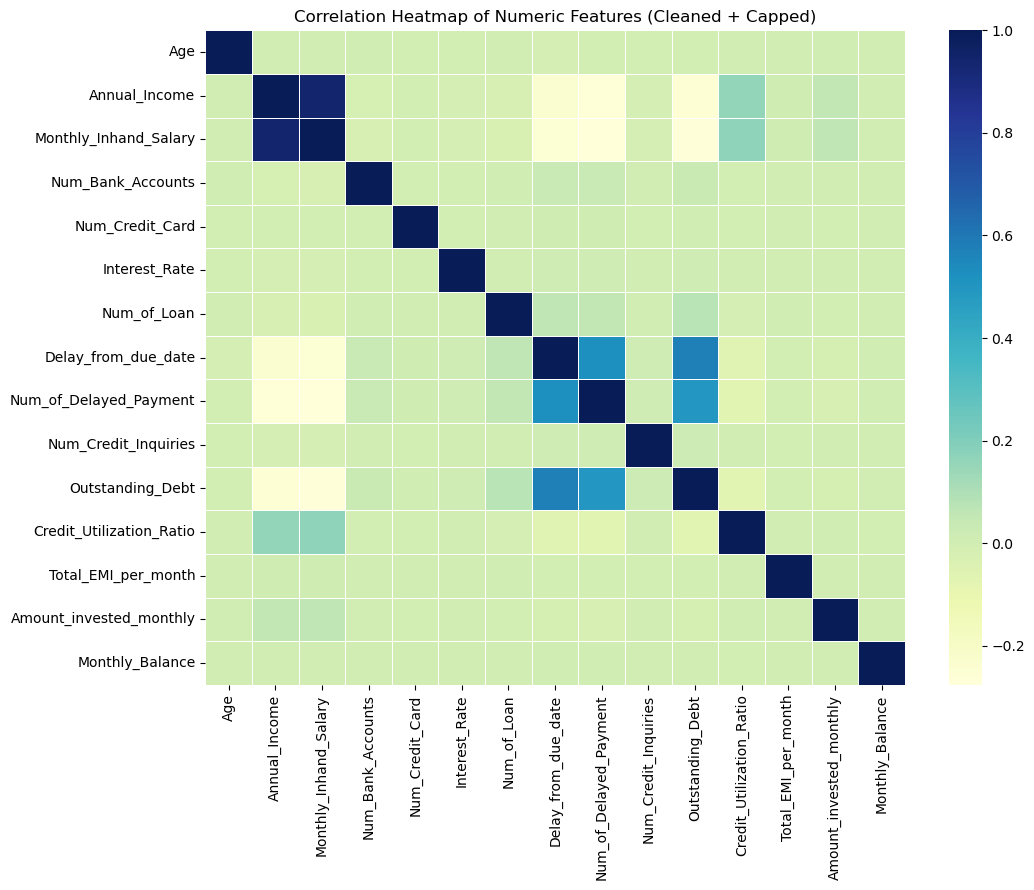

In [128]:
# Correlation heatmap

# Create cleaned numeric copy
df_corr = df.copy()

# Define candidate numeric columns (from your list)
numeric_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]


# Fix dtype issues
for col in numeric_cols:
    df_corr[col] = (
        df_corr[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("_", "", regex=False)
    )
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Handle invalid values
df_corr.loc[df_corr["Age"] < 0, "Age"] = np.nan
df_corr.loc[df_corr["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan

# Cap outliers at 99th percentile
for col in numeric_cols:
    if df_corr[col].dtype in [np.float64, np.int64]:
        cap = df_corr[col].quantile(0.99)
        df_corr[col] = np.minimum(df_corr[col], cap)

# Compute correlation matrix
corr_matrix = df_corr[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features (Cleaned + Capped)")
plt.tight_layout()
plt.show()


In [120]:
# Data Cleaning
df_clean = df.copy()

def clean_numeric(s):
    return (
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("_", "", regex=False)
         .replace(["NA", "NM", "None", ""], np.nan)
    )

numeric_object_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
]

for col in numeric_object_cols:
    df_clean[col] = clean_numeric(df_clean[col])
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Age impossible (<0 or >100)
df_clean = df_clean[(df_clean["Age"] > 0) & (df_clean["Age"] < 100)]

# Num_of_Loan cannot be negative
df_clean = df_clean[df_clean["Num_of_Loan"] >= 0]

# Num_of_Delayed_Payment cannot be negative
df_clean = df_clean[(df_clean["Num_of_Delayed_Payment"] >= 0)]

# Outstanding_Debt cannot be negative
df_clean = df_clean[(df_clean["Outstanding_Debt"] >= 0)]

# Credit_Utilization_Ratio cannot be negative or above 100
# (if >100 it's fraud but not impossible, so only drop <0 here)
df_clean = df_clean[df_clean["Credit_Utilization_Ratio"] >= 0]

# Delay_from_due_date cannot be negative
df_clean = df_clean[df_clean["Delay_from_due_date"] >= 0]

# Interest rate cannot exceed 100% in any real consumer loan scenario
df_clean = df_clean[df_clean["Interest_Rate"] <= 100]

# Monthly_Balance: remove thousand separators and cast to numeric
df_clean["Monthly_Balance"] = (
    df_clean["Monthly_Balance"]
    .astype(str)
    .str.replace(",", "")
)
df_clean["Monthly_Balance"] = pd.to_numeric(df_clean["Monthly_Balance"], errors="coerce")

# Parse Credit_History_Age: "XX Years and YY Months" -> total months
def parse_credit_age(x):
    if pd.isna(x):
        return np.nan
    parts = x.split(" ")
    years = int(parts[0])
    months = int(parts[3])
    return years * 12 + months

df_clean["Credit_History_Age"] = df_clean["Credit_History_Age"].apply(parse_credit_age)

print("Shape before cleaning:", df.shape)
print("Shape after cleaning :", df_clean.shape)
print(df_clean.info())
print(df_clean.head())
print(df_clean.describe())



Shape before cleaning: (100000, 28)
Shape after cleaning : (84083, 28)
<class 'pandas.core.frame.DataFrame'>
Index: 84083 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        84083 non-null  object 
 1   Customer_ID               84083 non-null  object 
 2   Month                     84083 non-null  object 
 3   Name                      75673 non-null  object 
 4   Age                       84083 non-null  int64  
 5   SSN                       84083 non-null  object 
 6   Occupation                84083 non-null  object 
 7   Annual_Income             84083 non-null  float64
 8   Monthly_Inhand_Salary     71456 non-null  float64
 9   Num_Bank_Accounts         84083 non-null  int64  
 10  Num_Credit_Card           84083 non-null  int64  
 11  Interest_Rate             84083 non-null  int64  
 12  Num_of_Loan               84083 non-null  int64  


In [121]:
# Check whether the dataset satisfies I.I.D. assumptions before dropping non-predictive ID columns

# 1. Each Customer_ID should map to only one SSN
cid_ssn_conflict = df_clean.groupby("Customer_ID")["SSN"].transform("nunique") > 1

# 2. Each Customer_ID should map to only one Name
cid_name_conflict = df_clean.groupby("Customer_ID")["Name"].transform("nunique") > 1

# 3. Each SSN should map to only one Customer_ID
ssn_cid_conflict = df_clean.groupby("SSN")["Customer_ID"].transform("nunique") > 1

# 4. Each SSN should map to only one Name
ssn_name_conflict = df_clean.groupby("SSN")["Name"].transform("nunique") > 1

# 5. ID should be unique, but check for safety
id_conflict = df_clean["ID"].duplicated(keep=False)

# Combine all conflict conditions
conflict_mask = (
    cid_ssn_conflict |
    cid_name_conflict |
    ssn_cid_conflict |
    ssn_name_conflict |
    id_conflict
)

# Rows that violate I.I.D.
conflict_rows = df_clean[conflict_mask]

# Keep only consistent rows
clean_df = df_clean[~conflict_mask].copy()

print("Total rows:", len(df_clean))
print("Misaligned rows detected:", len(conflict_rows))
print("Remaining clean rows:", len(clean_df))

# Count unique valid person signatures
unique_persons = clean_df[["Customer_ID", "SSN", "Name"]].value_counts()
print("Number of unique persons:", len(unique_persons))
print(unique_persons.head())

# Summary of dropped rows
print("Rows originally:", len(df_clean))
print("Rows in clean_df:", len(clean_df))
print("Rows dropped:", len(df_clean) - len(clean_df))

# Validate that each ID mapping is now unique
print("Customer_ID → SSN unique max:", clean_df.groupby("Customer_ID")["SSN"].nunique().max())
print("Customer_ID → Name unique max:", clean_df.groupby("Customer_ID")["Name"].nunique().max())
print("SSN → Customer_ID unique max:", clean_df.groupby("SSN")["Customer_ID"].nunique().max())
print("SSN → Name unique max:", clean_df.groupby("SSN")["Name"].nunique().max())

"""
Before preprocessing, I retained the identifier columns (Customer_ID, SSN, and Name) because each person appears multiple times in the dataset (8 monthly records per individual). Removing these identifiers too early would allow records from the same person to be split across the training and test sets, causing severe data leakage.
To prevent this, I performed a grouped train/validation/test split using Customer_ID as the grouping key, ensuring that all records of a person remain in the same split.
After the split was completed, these identifier columns were removed since they are not predictive features.
"""

Total rows: 84083
Misaligned rows detected: 27261
Remaining clean rows: 56822
Number of unique persons: 8532
Customer_ID  SSN          Name         
CUS_0x558f   060-58-0187  Wroughtonw       8
CUS_0x6eca   229-06-8015  Daniel Basesq    8
CUS_0xa95    665-52-4675  Stevev           8
CUS_0x6d85   771-46-0192  Alwyn Scotto     8
CUS_0xa93b   831-44-6626  Herbert Lashf    8
Name: count, dtype: int64
Rows originally: 84083
Rows in clean_df: 56822
Rows dropped: 27261
Customer_ID → SSN unique max: 1
Customer_ID → Name unique max: 1
SSN → Customer_ID unique max: 1
SSN → Name unique max: 1


'\nBefore preprocessing, I retained the identifier columns (Customer_ID, SSN, and Name) because each person appears multiple times in the dataset (8 monthly records per individual). Removing these identifiers too early would allow records from the same person to be split across the training and test sets, causing severe data leakage.\nTo prevent this, I performed a grouped train/validation/test split using Customer_ID as the grouping key, ensuring that all records of a person remain in the same split.\nAfter the split was completed, these identifier columns were removed since they are not predictive features.\n'

In [122]:
# Check missing values for each column which are not written as NA
for col in clean_df.columns:
    uniques = clean_df[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(uniques)}")
    # Only print first 20 to avoid flooding
    print(uniques[:20])


--- ID ---
Unique count: 56822
['0x160e' '0x160f' '0x1611' '0x1612' '0x1613' '0x1614' '0x1615' '0x161a'
 '0x161b' '0x161c' '0x161d' '0x161e' '0x161f' '0x1620' '0x1621' '0x1635'
 '0x1636' '0x1637' '0x1638' '0x163e']

--- Customer_ID ---
Unique count: 8532
['CUS_0x21b1' 'CUS_0x2dbc' 'CUS_0x1cdb' 'CUS_0x95ee' 'CUS_0x5407'
 'CUS_0x4157' 'CUS_0xba08' 'CUS_0xa66b' 'CUS_0xc0ab' 'CUS_0x6c66'
 'CUS_0xff4' 'CUS_0xfdb' 'CUS_0x3553' 'CUS_0xa16e' 'CUS_0xac86'
 'CUS_0x5b48' 'CUS_0xb95f' 'CUS_0x3edc' 'CUS_0xb681' 'CUS_0x9a71']

--- Month ---
Unique count: 8
['January' 'February' 'April' 'May' 'June' 'July' 'August' 'March']

--- Name ---
Unique count: 7390
['Rick Rothackerj' 'Langep' nan 'Deepaa' 'Np' 'Annk' 'Charlie Zhur'
 'Jamesj' 'Saphirj' 'Soyoungd' 'Sinead Carews' 'Poornimaf' 'Patrickg'
 'Laurence Frosty' 'Lee Chyenz' 'Nickb' 'McBrideq' 'Ashleyk' 'Williamso'
 'Sarahb']

--- Age ---
Unique count: 45
[28 34 21 31 30 23 24 44 40 41 33 39 36 37 45 46 26 42 19 20]

--- SSN ---
Unique count: 8532
['0

In [123]:
# Handle special missing value tokens in categorical columns
missing_tokens = ["_", "_______", "!@9#%8", "NM"]

for col in ["Occupation", "Credit_Mix", "Payment_Behaviour", "Payment_of_Min_Amount"]:
    df_clean[col] = df_clean[col].replace(missing_tokens, np.nan)

# Drop ID because it's non-predictive and unique for each row， keep SSN, Customer_ID, Name for potential grouped splitting later but not for modeling
df_clean = df_clean.drop(columns=["ID"])

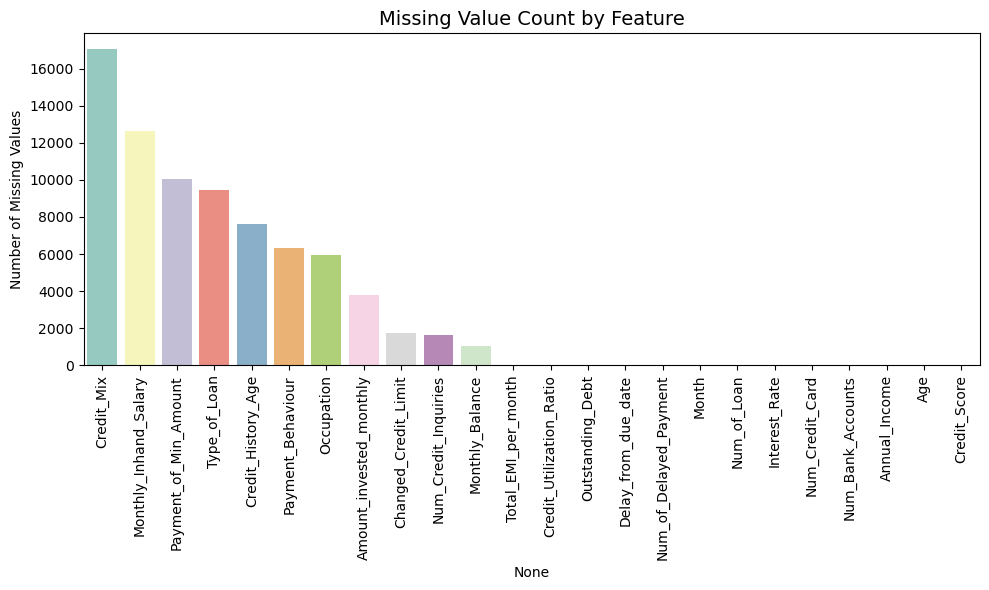

In [124]:
# Re-run the EDA visualizations on clean_df as needed
# Missing values per column in clean_df
missing_counts = df_clean.isnull().sum().sort_values(ascending=False)

# Columns to exclude
exclude_cols = ["Name", "SSN", "Customer_ID"]

# Remove excluded columns
missing_counts = missing_counts.drop(labels=[c for c in exclude_cols if c in missing_counts.index])

plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_counts.index,
    y=missing_counts.values,
    hue=missing_counts.index,
    palette="Set3"
)
plt.title("Missing Value Count by Feature", fontsize=14)
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

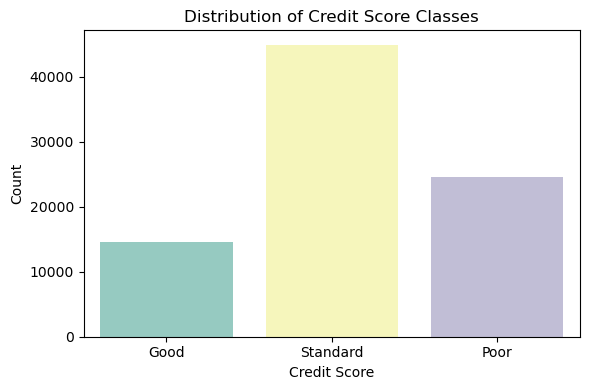

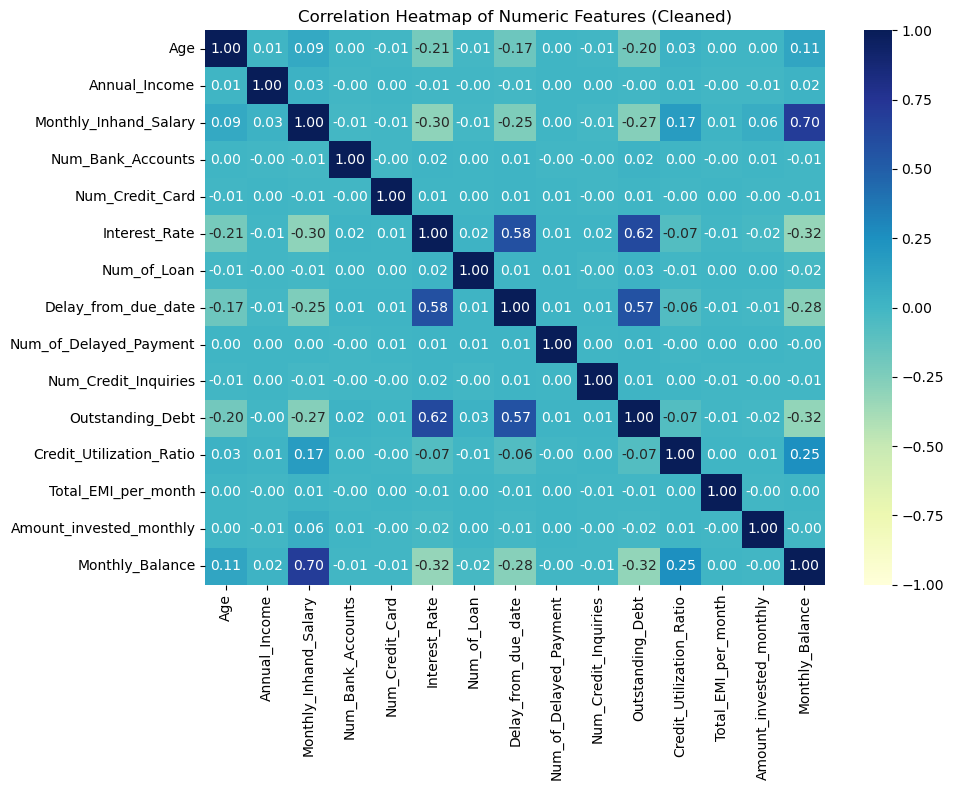

In [137]:
# Re-run some of the previous EDA plots on clean_df if needed
# The distribution of Credit_Score after cleaning
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Credit_Score",hue="Credit_Score", palette="Set3")
plt.title("Distribution of Credit Score Classes")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Heatmap of correlations in clean_df
numeric_cols = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
    "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date",
    "Num_of_Delayed_Payment", "Num_Credit_Inquiries", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Total_EMI_per_month",
    "Amount_invested_monthly", "Monthly_Balance"
]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="YlGnBu",
    vmin=-1, vmax=1,      
    annot=True, fmt=".2f"
)
plt.title("Correlation Heatmap of Numeric Features (Cleaned)")
plt.tight_layout()
plt.show()
